In [197]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import statistics
import seaborn as sns
from sklearn import metrics
from scipy.spatial.distance import cdist
from sklearn import preprocessing as prep

Overwriting app.py


In [21]:
dataset_red = "wine-data/winequality-red.xlsx"
dataset_white = "wine-data/winequality-white.xlsx"

df_red = pd.read_excel(dataset_red, header=1)
df_white = pd.read_excel(dataset_white, header=1)

df_red.isna().sum()

df_white.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [31]:
df_categorical = df_red.select_dtypes(exclude=[np.number])

df_categorical




""
0
1
2
3
4
...
1594
1595
1596
1597


In [209]:
df_red['type'] = 'red'
df_white['type'] = 'white'



df = pd.concat([df_red, df_white], ignore_index=True)

df.to_csv('wine.csv', index=False)  

df['type'] = df['type'].replace({"red": 1, "white": 0})
df

/var/folders/_9/1wncpzhj5lg0z06jsr1f9f0c0000gn/T/ipykernel_78682/491436599.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['type'] = df['type'].replace({"red": 1, "white": 0})


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0


In [33]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                      int64
dtype: object

Red: alcohol
White: alcohol


In [37]:
print("Red: ", df_red.mean())
print("White:", df_white.mean())

Red:  fixed acidity            8.319637
volatile acidity         0.527821
citric acid              0.270976
residual sugar           2.538806
chlorides                0.087467
free sulfur dioxide     15.874922
total sulfur dioxide    46.467792
density                  0.996747
pH                       3.311113
sulphates                0.658149
alcohol                 10.422983
quality                  5.636023
dtype: float64
White: fixed acidity             6.854788
volatile acidity          0.278241
citric acid               0.334192
residual sugar            6.391415
chlorides                 0.045772
free sulfur dioxide      35.308085
total sulfur dioxide    138.360657
density                   0.994027
pH                        3.188267
sulphates                 0.489847
alcohol                  10.514267
quality                   5.877909
dtype: float64


In [39]:
print("Red: ", df_red.median())
print("White:", df_white.median())

Red:  fixed acidity            7.90000
volatile acidity         0.52000
citric acid              0.26000
residual sugar           2.20000
chlorides                0.07900
free sulfur dioxide     14.00000
total sulfur dioxide    38.00000
density                  0.99675
pH                       3.31000
sulphates                0.62000
alcohol                 10.20000
quality                  6.00000
dtype: float64
White: fixed acidity             6.80000
volatile acidity          0.26000
citric acid               0.32000
residual sugar            5.20000
chlorides                 0.04300
free sulfur dioxide      34.00000
total sulfur dioxide    134.00000
density                   0.99374
pH                        3.18000
sulphates                 0.47000
alcohol                  10.40000
quality                   6.00000
dtype: float64


In [41]:
df.corr(numeric_only=True)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.076743,0.486740
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.265699,0.653036
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.085532,-0.187397
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.036980,-0.348821
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.200666,0.512678
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.055463,-0.471644
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.041385,-0.700357
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.305858,0.390645
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.019506,0.329129
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.038485,0.487218


In [49]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.246114
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


fixed acidity: Ikke normalfordelt (p=0.0000000000)
volatile acidity: Ikke normalfordelt (p=0.0000000000)
citric acid: Ikke normalfordelt (p=0.0000000000)
residual sugar: Ikke normalfordelt (p=0.0000000000)
chlorides: Ikke normalfordelt (p=0.0000000000)
free sulfur dioxide: Ikke normalfordelt (p=0.0000000000)
total sulfur dioxide: Ikke normalfordelt (p=0.0000000000)
density: Ikke normalfordelt (p=0.0000000000)
pH: Ikke normalfordelt (p=0.0000000000)
sulphates: Ikke normalfordelt (p=0.0000000000)
alcohol: Ikke normalfordelt (p=0.0000000000)
quality: Ikke normalfordelt (p=0.0000000000)
type: Ikke normalfordelt (p=0.0000000000)


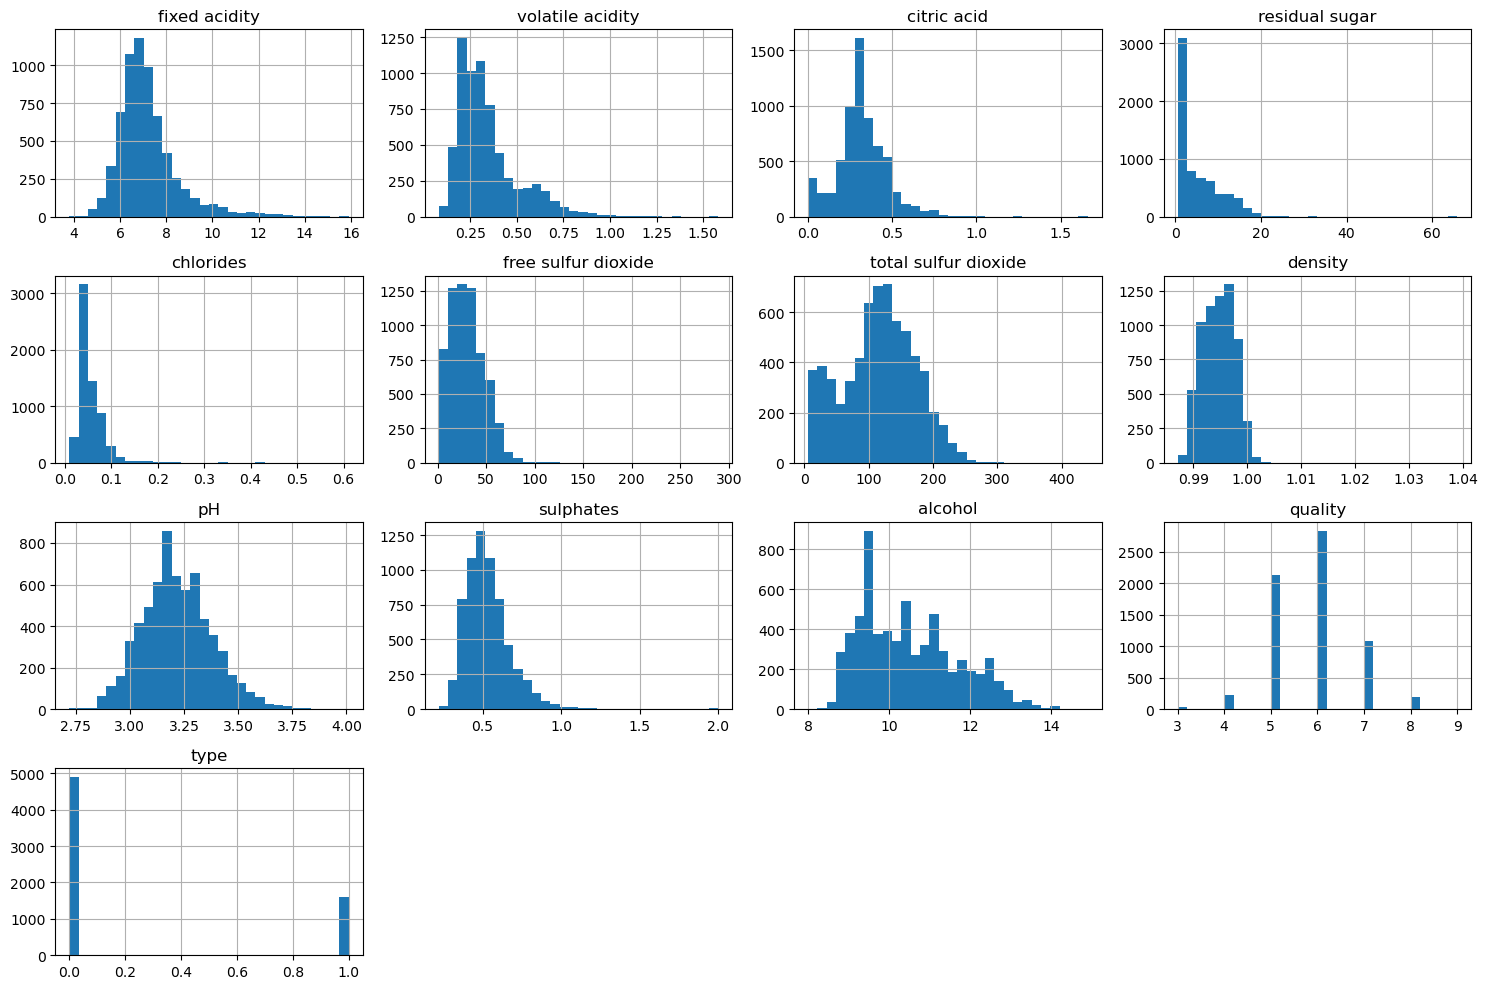

In [61]:
from scipy.stats import normaltest

for column in df.select_dtypes(include='number').columns:
    stat, p = normaltest(df[column])
    if p < 0.05:
        print(f"{column}: Ikke normalfordelt (p={p:.10f})")
     

    else:
        print(f"{column}: Normalfordelt (p={p:.4f})")


df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

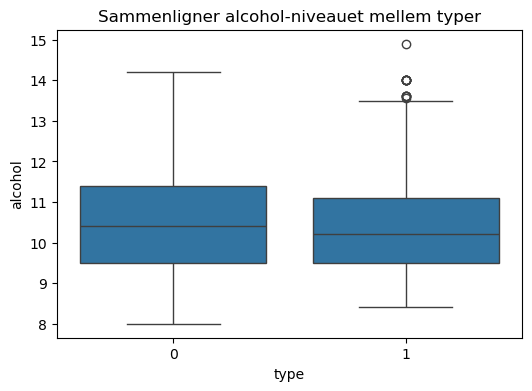

In [95]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='type', y='alcohol')
plt.title('Sammenligner alcohol-niveauet mellem typer')
plt.show()

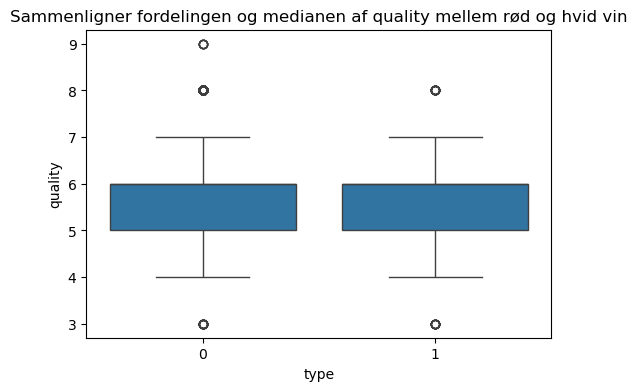

In [97]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='type', y='quality')
plt.title('Sammenligner fordelingen og medianen af quality mellem rød og hvid vin')
plt.show()

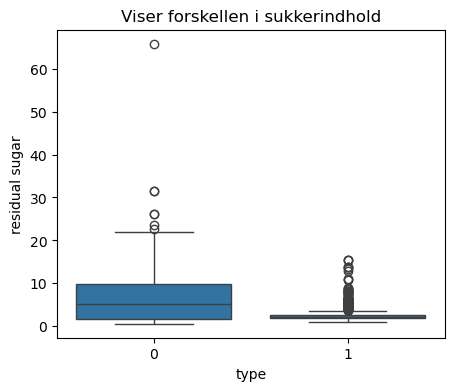

In [99]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x='type', y='residual sugar')
plt.title('Viser forskellen i sukkerindhold')
plt.show()

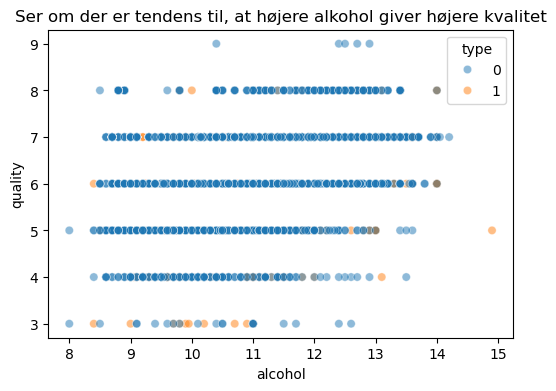

In [101]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='type', alpha=0.5)
plt.title("Ser om der er tendens til, at højere alkohol giver højere kvalitet")
plt.show()

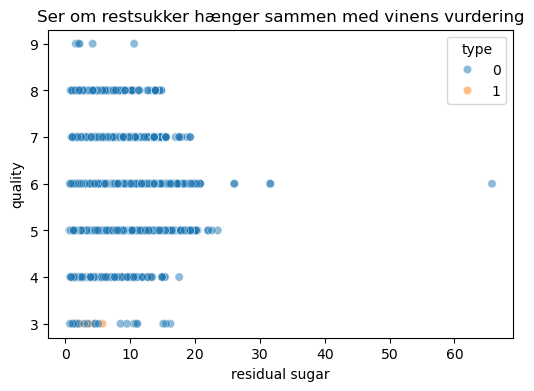

In [103]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='residual sugar', y='quality', hue='type', alpha=0.5)
plt.title("Ser om restsukker hænger sammen med vinens vurdering")
plt.show()

In [105]:
#Hvilken type har højere kvalitet
print(df.groupby('type')['quality'].mean())


type
0    5.877909
1    5.636023
Name: quality, dtype: float64


In [107]:
#Hvilken type har højere alkohol
print(df.groupby('type')['alcohol'].mean())


type
0    10.514267
1    10.422983
Name: alcohol, dtype: float64


In [109]:
#Hvem har mere residual sugar
print(df.groupby('type')['residual sugar'].mean())


type
0    6.391415
1    2.538806
Name: residual sugar, dtype: float64


In [111]:
#Påvirker alkohol og restsukker kvaliteten
print(df[['alcohol', 'residual sugar', 'quality']].corr())


                 alcohol  residual sugar   quality
alcohol         1.000000       -0.359415  0.444319
residual sugar -0.359415        1.000000 -0.036980
quality         0.444319       -0.036980  1.000000


In [113]:
df['pH_bin_5'] = pd.cut(df['pH'], bins=5)
density_by_bin_5 = df.groupby('pH_bin_5')['density'].mean()
print("Binning i 5 grupper:")
print(density_by_bin_5)

Binning i 5 grupper:
pH_bin_5
(2.719, 2.978]    0.994801
(2.978, 3.236]    0.994679
(3.236, 3.494]    0.994688
(3.494, 3.752]    0.994887
(3.752, 4.01]     0.993582
Name: density, dtype: float64


/var/folders/_9/1wncpzhj5lg0z06jsr1f9f0c0000gn/T/ipykernel_78682/1827845238.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  density_by_bin_5 = df.groupby('pH_bin_5')['density'].mean()


In [115]:
df['pH_bin_10'] = pd.cut(df['pH'], bins=10)
density_by_bin_10 = df.groupby('pH_bin_10')['density'].mean()
print("Binning i 10 grupper:")
print(density_by_bin_10)

Binning i 10 grupper:
pH_bin_10
(2.719, 2.849]    0.993112
(2.849, 2.978]    0.994882
(2.978, 3.107]    0.994706
(3.107, 3.236]    0.994664
(3.236, 3.365]    0.994515
(3.365, 3.494]    0.995044
(3.494, 3.623]    0.994942
(3.623, 3.752]    0.994640
(3.752, 3.881]    0.993888
(3.881, 4.01]     0.992665
Name: density, dtype: float64


/var/folders/_9/1wncpzhj5lg0z06jsr1f9f0c0000gn/T/ipykernel_78682/1475503761.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  density_by_bin_10 = df.groupby('pH_bin_10')['density'].mean()


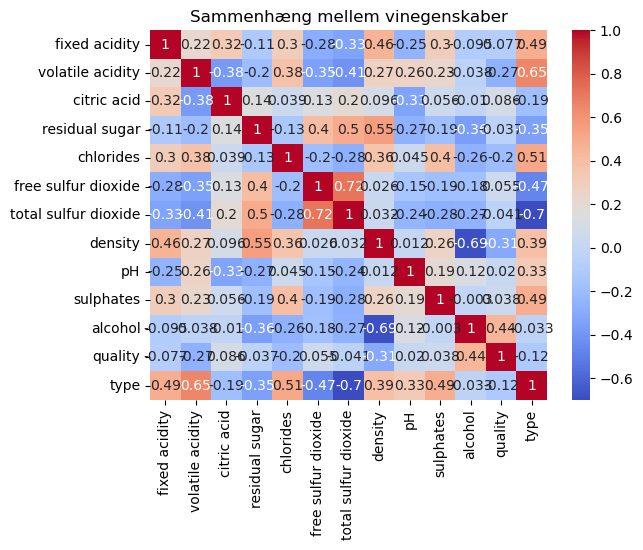

In [215]:
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Sammenhæng mellem vinegenskaber")
plt.show()

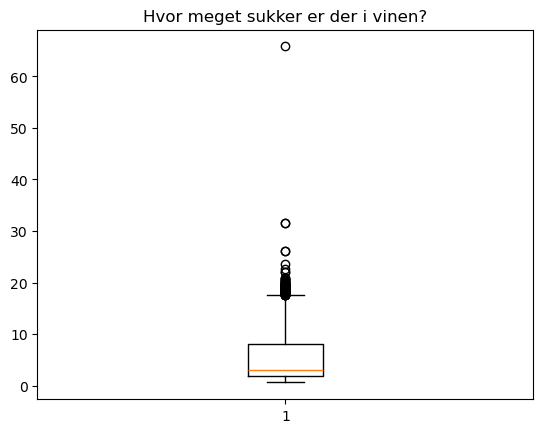

In [121]:
plt.boxplot(df['residual sugar'])
plt.title("Hvor meget sukker er der i vinen?")
plt.show()

In [127]:
#normale værdier
Q1 = df['residual sugar'].quantile(0.25)  # Nedre grænse for normalt sukker
Q3 = df['residual sugar'].quantile(0.75)  # Øvre grænse for normalt sukker
IQR = Q3 - Q1

lav_grænse = Q1 - 1.5 * IQR
høj_grænse = Q3 + 1.5 * IQR

In [131]:
#outliers
outliers = df[(df['residual sugar'] < lav_grænse) | 
                      (df['residual sugar'] > høj_grænse)]
print(f"Antal vine med mærkeligt sukkerindhold: {len(outliers)}")

#fjern outliers
rem_wine = df[(df['residual sugar'] >= lav_grænse) & 
                (df['residual sugar'] <= høj_grænse)]
print(f"Før: {len(df)} vine | Efter oprydning: {len(rem_wine)} vine")

print(outliers[['type', 'residual sugar']].head())
wine_clean = df[df['residual sugar'] <= høj_grænse]

Antal vine med mærkeligt sukkerindhold: 118
Før: 6497 vine | Efter oprydning: 6379 vine
      type  residual sugar
1599     0           20.70
1606     0           20.70
1613     0           19.25
1637     0           17.95
1638     0           17.95


In [139]:
wine_clean = wine_clean.drop(['residual sugar', 'free sulfur dioxide'], axis=1)




KeyError: "['residual sugar', 'free sulfur dioxide'] not found in axis"

In [143]:
df.dtypes

fixed acidity            float64
volatile acidity         float64
citric acid              float64
residual sugar           float64
chlorides                float64
free sulfur dioxide      float64
total sulfur dioxide     float64
density                  float64
pH                       float64
sulphates                float64
alcohol                  float64
quality                    int64
type                       int64
pH_bin_5                category
pH_bin_10               category
dtype: object

In [145]:
num_data = wine_clean.select_dtypes(include=['float64', 'int64'])


In [153]:
num_data = num_data.values
num_data

array([[ 7.4 ,  0.7 ,  0.  , ...,  9.4 ,  5.  ,  1.  ],
       [ 7.8 ,  0.88,  0.  , ...,  9.8 ,  5.  ,  1.  ],
       [ 7.8 ,  0.76,  0.04, ...,  9.8 ,  5.  ,  1.  ],
       ...,
       [ 6.5 ,  0.24,  0.19, ...,  9.4 ,  6.  ,  0.  ],
       [ 5.5 ,  0.29,  0.3 , ..., 12.8 ,  7.  ,  0.  ],
       [ 6.  ,  0.21,  0.38, ..., 11.8 ,  6.  ,  0.  ]])

In [155]:
nl1 = prep.normalize(num_data, norm='l1')
nl1

array([[0.11812821, 0.01117429, 0.        , ..., 0.15005475, 0.07981636,
        0.01596327],
       [0.08086689, 0.00912344, 0.        , ..., 0.10160199, 0.05183775,
        0.01036755],
       [0.0935263 , 0.00911282, 0.00047962, ..., 0.1175074 , 0.05995276,
        0.01199055],
       ...,
       [0.04716518, 0.00174148, 0.00137867, ..., 0.0682081 , 0.04353709,
        0.        ],
       [0.03911231, 0.00206229, 0.0021334 , ..., 0.09102501, 0.0497793 ,
        0.        ],
       [0.04725176, 0.00165381, 0.00299261, ..., 0.09292845, 0.04725176,
        0.        ]])

In [157]:
nl2 = prep.normalize(num_data, norm='l2')
nl2

array([[0.20220956, 0.01912793, 0.        , ..., 0.2568608 , 0.13662808,
        0.02732562],
       [0.11396447, 0.01285753, 0.        , ..., 0.14318613, 0.07305415,
        0.01461083],
       [0.13983274, 0.01362473, 0.00071709, ..., 0.17568729, 0.08963637,
        0.01792727],
       ...,
       [0.05814279, 0.00214681, 0.00169956, ..., 0.08408341, 0.05367026,
        0.        ],
       [0.04948024, 0.00260896, 0.00269892, ..., 0.11515401, 0.06297485,
        0.        ],
       [0.06052541, 0.00211839, 0.00383328, ..., 0.1190333 , 0.06052541,
        0.        ]])

In [159]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()  
num_data = sc.fit_transform(num_data)  
num_data

array([[ 0.13740324,  2.17278009, -2.19713103, ..., -0.93852397,
        -0.94230528,  1.72897899],
       [ 0.44409798,  3.26101352, -2.19713103, ..., -0.60143541,
        -0.94230528,  1.72897899],
       [ 0.44409798,  2.53552456, -1.92052344, ..., -0.60143541,
        -0.94230528,  1.72897899],
       ...,
       [-0.55265994, -0.6082609 , -0.883245  , ..., -0.93852397,
         0.19959544, -0.57837603],
       [-1.31939679, -0.30597384, -0.12257415, ...,  1.92672873,
         1.34149615, -0.57837603],
       [-0.93602837, -0.78963314,  0.43064102, ...,  1.08400735,
         0.19959544, -0.57837603]])

In [161]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
num_data = sc.fit_transform(num_data)  
num_data

array([[0.29752066, 0.41333333, 0.        , ..., 0.20289855, 0.33333333,
        1.        ],
       [0.33057851, 0.53333333, 0.        , ..., 0.26086957, 0.33333333,
        1.        ],
       [0.33057851, 0.45333333, 0.02409639, ..., 0.26086957, 0.33333333,
        1.        ],
       ...,
       [0.2231405 , 0.10666667, 0.11445783, ..., 0.20289855, 0.5       ,
        0.        ],
       [0.14049587, 0.14      , 0.18072289, ..., 0.69565217, 0.66666667,
        0.        ],
       [0.18181818, 0.08666667, 0.22891566, ..., 0.55072464, 0.5       ,
        0.        ]])

In [163]:
from sklearn.decomposition import PCA
pca = PCA()
pca_data = pca.fit_transform(num_data)
pca_data

array([[ 8.50967862e-01, -1.08100570e-01, -2.56970531e-01, ...,
        -4.68288833e-03,  3.01269411e-02, -3.24921255e-03],
       [ 8.33504544e-01, -8.48503999e-02, -1.57423851e-01, ...,
         8.86741348e-03,  2.58227527e-02, -1.03229403e-02],
       [ 8.29819044e-01, -8.00316332e-02, -1.50343174e-01, ...,
        -9.98764695e-03,  1.60023456e-02, -5.03142322e-03],
       ...,
       [-2.85742168e-01, -6.55836540e-02,  9.61395171e-03, ...,
        -3.08251922e-02,  3.47108708e-02, -1.81101832e-02],
       [-3.43033904e-01,  4.98023580e-01, -6.60345393e-02, ...,
         3.62248828e-02, -8.00568722e-03, -2.27480671e-03],
       [-3.29985302e-01,  3.10203941e-01, -8.46010374e-02, ...,
         3.70412606e-02, -3.54249654e-04, -1.54265159e-02]])

In [165]:
explained_variance = pca.explained_variance_ratio_  
explained_variance

array([0.62938161, 0.16014419, 0.06119654, 0.04701615, 0.02549308,
       0.02170082, 0.01724086, 0.01341808, 0.01069801, 0.00820098,
       0.00550969])

/var/folders/_9/1wncpzhj5lg0z06jsr1f9f0c0000gn/T/ipykernel_78682/1406135175.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(explained_variance, 'bx-', c='red')


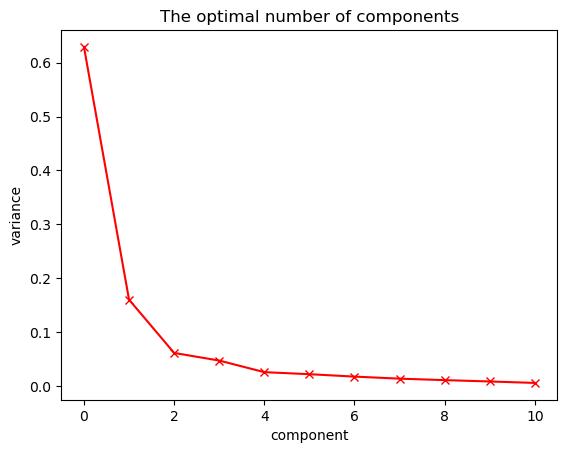

In [167]:
plt.plot(explained_variance, 'bx-', c='red')
plt.xlabel('component')
plt.ylabel('variance')
plt.title('The optimal number of components')
plt.show()

/var/folders/_9/1wncpzhj5lg0z06jsr1f9f0c0000gn/T/ipykernel_78682/2643123768.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b*-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(cumulative, 'b*-', c='green')


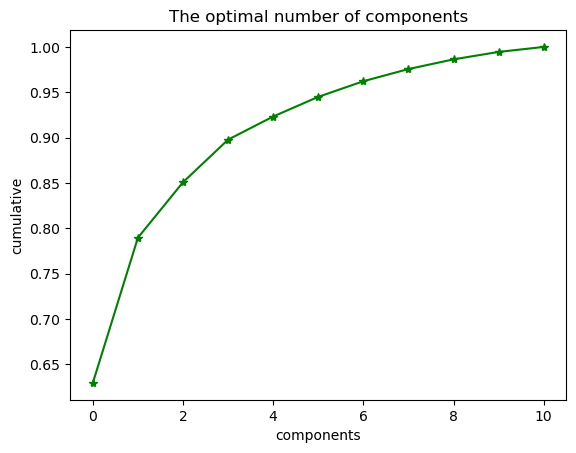

In [169]:
cumulative = np.cumsum(explained_variance)
plt.plot(cumulative, 'b*-', c='green')
plt.xlabel('components')
plt.ylabel('cumulative')
plt.title('The optimal number of components')
plt.show()


In [173]:
pca = PCA(n_components=3)
pca_data = pca.fit_transform(num_data)
pca_data

array([[ 0.85096786, -0.10810057, -0.25697053],
       [ 0.83350454, -0.0848504 , -0.15742385],
       [ 0.82981904, -0.08003163, -0.15034317],
       ...,
       [-0.28574217, -0.06558365,  0.00961395],
       [-0.3430339 ,  0.49802358, -0.06603454],
       [-0.3299853 ,  0.31020394, -0.08460104]])

In [211]:
pcadf = pd.DataFrame(data = pca_data, columns = ['pc 1', 'pc 2', 'pc 3'])
pcadf
pcadf.to_csv('pca.csv', index=False)

In [185]:
random = wine_clean.sample(10)
random

,fixed acidity,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,pH_bin_5,pH_bin_10
3649,11.8,0.230,0.38,0.034,123.0,0.99970,2.93,0.55,9.7,3,0,"(2.719, 2.978]","(2.849, 2.978]"
3243,7.3,0.190,0.49,0.058,134.0,0.99980,3.42,0.36,9.1,7,0,"(3.236, 3.494]","(3.365, 3.494]"
5557,5.6,0.185,0.19,0.048,110.0,0.99438,3.26,0.41,9.5,6,0,"(3.236, 3.494]","(3.236, 3.365]"
782,9.0,0.820,0.05,0.081,96.0,0.99814,3.36,0.53,10.0,5,1,"(3.236, 3.494]","(3.236, 3.365]"
149,8.2,0.400,0.44,0.089,43.0,0.99750,3.53,0.61,10.5,6,1,"(3.494, 3.752]","(3.494, 3.623]"
1986,6.3,0.390,0.35,0.040,260.0,0.99410,3.12,0.66,10.1,5,0,"(2.978, 3.236]","(3.107, 3.236]"
1303,8.0,0.280,0.44,0.081,68.0,0.99501,3.36,0.66,11.2,5,1,"(3.236, 3.494]","(3.236, 3.365]"
2667,8.8,0.330,0.44,0.024,87.0,0.99170,2.96,0.40,12.6,7,0,"(2.719, 2.978]","(2.849, 2.978]"
5014,6.1,0.300,0.30,0.031,163.0,0.98950,3.39,0.43,12.7,7,0,"(3.236, 3.494]","(3.365, 3.494]"
6140,6.0,0.230,0.34,0.025,111.0,0.98961,3.36,0.37,12.7,6,0,"(3.236, 3.494]","(3.236, 3.365]"


In [189]:
print(random[['type', 'alcohol', 'volatile acidity', 'quality']]) 
 
random.to_csv('tilfældige_vine.csv', index=False)  

      type  alcohol  volatile acidity  quality
3649     0      9.7             0.230        3
3243     0      9.1             0.190        7
5557     0      9.5             0.185        6
782      1     10.0             0.820        5
149      1     10.5             0.400        6
1986     0     10.1             0.390        5
1303     1     11.2             0.280        5
2667     0     12.6             0.330        7
5014     0     12.7             0.300        7
6140     0     12.7             0.230        6


In [207]:
import streamlit as st
import pandas as pd

st.title("Wine")

# Læs data fra CSV
df = pd.read_csv("tilfældige_vine.csv")
st.write(df)